This code will give data visualizations rather than just tables; this is a separate file to keep things from getting too cluttered

The following figures display the sampled points as categorical 60 × 60 grids.  
Each cell represents one observed point, and no values are interpolated between
points. The cells are shown next to one another for visualization purposes and
do not represent continuous land-cover coverage or the physical spacing between
sample locations

In [9]:
# Import everything

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [10]:
# Set up necessary values

allData = pd.read_csv("allData.csv")

# Just going to define the classes here
allDataClasses = ["Tree cover", "Grassland", "Shrubland",
                  "Bare/sparse vegetation", "Permanent water bodies",
                  "Built-up", "Cropland", "Herbaceous Wetland"]

true_labels = allData['crosswalked label (student data)']
predicted_labels = allData['Model label (worldcover)']

def construct_aoi_grid(labels):
    blocks = np.asarray(labels).reshape(6, 6, 10, 10)

    # PSU row, internal row, PSU column, internal column
    return blocks.transpose(0, 2, 1, 3).reshape(60, 60)

ground_grid = construct_aoi_grid(true_labels.to_numpy())
model_grid = construct_aoi_grid(predicted_labels.to_numpy())

Point-Level Classification Grids


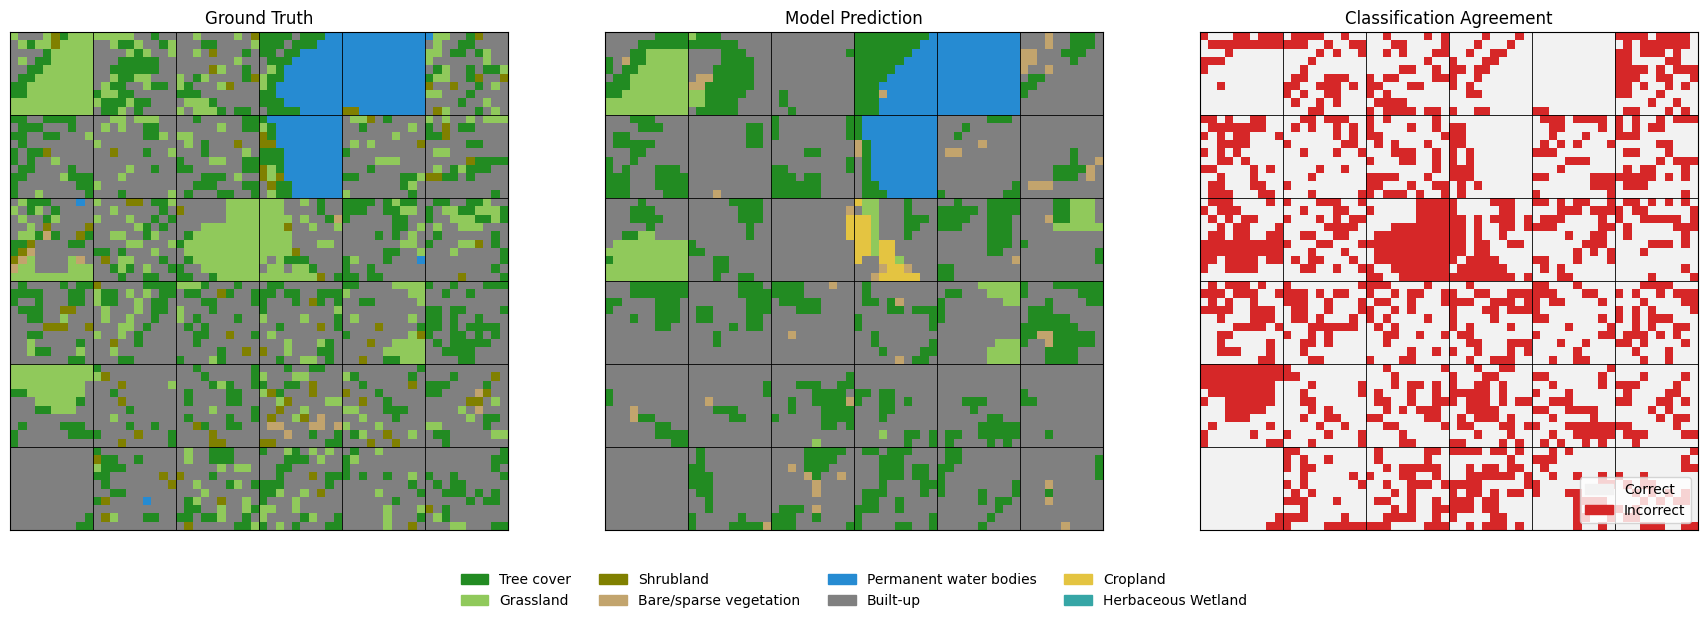

In [11]:
# Converting class names into integers for plotting
# This visualization assumes the CSV follows the row and PSU ordering described in the README.

print("Point-Level Classification Grids")

class_to_number = {
    class_name: number
    for number, class_name in enumerate(allDataClasses)
}

# __getitem__ raises an error if an unexpected class reaches this point
ground_numeric = np.vectorize(
    class_to_number.__getitem__
)(ground_grid)

model_numeric = np.vectorize(
    class_to_number.__getitem__
)(model_grid)

class_colors = [
    "#228B22",  # Tree cover
    "#90C95B",  # Grassland
    "#808000",  # Shrubland
    "#C2A46D",  # Bare/sparse vegetation
    "#268BD2",  # Permanent water bodies
    "#808080",  # Built-up
    "#E4C441",  # Cropland
    "#36A6A6"   # Herbaceous Wetland
]

cmap = ListedColormap(class_colors)

# Ensures that each class receives exactly one discrete color
norm = BoundaryNorm(
    np.arange(-0.5, len(allDataClasses) + 0.5),
    cmap.N
)

agreement_grid = (ground_numeric == model_numeric)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

# Ground-truth classification map
axes[0].imshow(
    ground_numeric,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    origin="lower"
)
axes[0].set_title("Ground Truth")

# Model classification map
axes[1].imshow(
    model_numeric,
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
    origin="lower"
)
axes[1].set_title("Model Prediction")

# Point-level agreement map
axes[2].imshow(
    agreement_grid,
    cmap=ListedColormap([
        "#D62728",  # Incorrect
        "#F2F2F2"   # Correct
    ]),
    vmin=0,
    vmax=1,
    interpolation="nearest",
    origin="lower"
)
axes[2].set_title("Classification Agreement")

for axis in axes:
    axis.set_xticks([])
    axis.set_yticks([])

    # Draw PSU boundaries
    for boundary in range(10, 60, 10):
        axis.axhline(
            boundary - 0.5,
            color="black",
            linewidth=0.6
        )
        axis.axvline(
            boundary - 0.5,
            color="black",
            linewidth=0.6
        )

# Land-cover legend
class_legend = [
    Patch(
        color=class_colors[index],
        label=class_name
    )
    for index, class_name in enumerate(allDataClasses)
]

fig.legend(
    handles=class_legend,
    loc="lower center",
    ncol=4,
    frameon=False
)

# Separate legend for the agreement panel
axes[2].legend(
    handles=[
        Patch(color="#F2F2F2", label="Correct"),
        Patch(color="#D62728", label="Incorrect")
    ],
    loc="lower right"
)

plt.tight_layout(rect=[0, 0.12, 1, 1])

plt.show()


# Calculating PSU-level accuracy
point_agreement = (true_labels.to_numpy() == predicted_labels.to_numpy())

psu_accuracy = (
    point_agreement
    .reshape(36, 100)
    .mean(axis=1)
    .reshape(6, 6)
    * 100
)

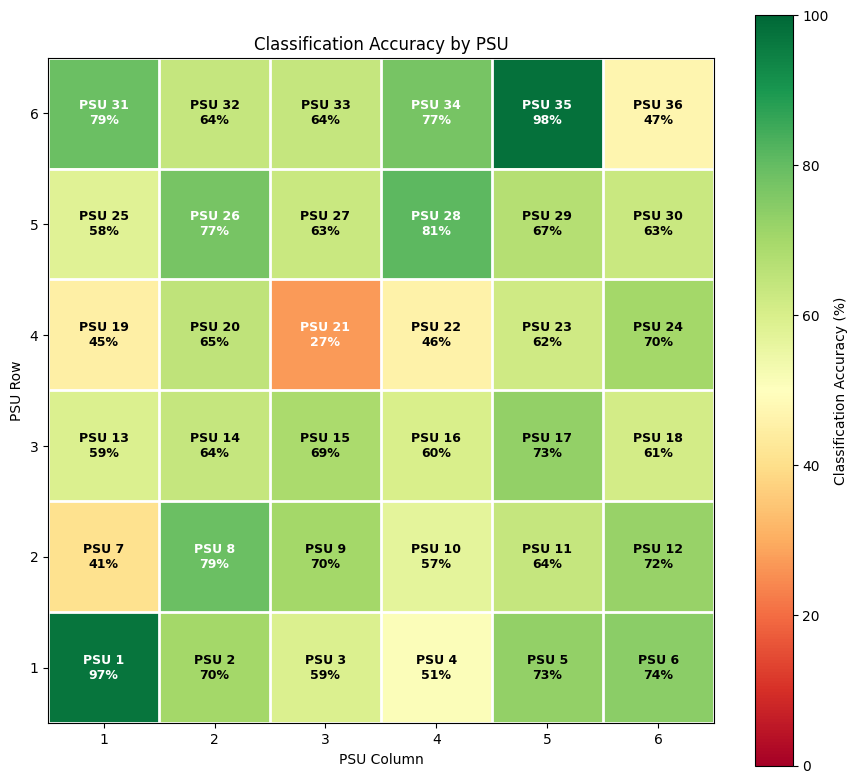

In [12]:
fig, axis = plt.subplots(figsize=(9, 8))

image = axis.imshow(
    psu_accuracy,
    cmap="RdYlGn",
    vmin=0,
    vmax=100,
    interpolation="nearest",
    origin="lower"
)

for row in range(6):
    for column in range(6):
        psu_number = row * 6 + column + 1
        accuracy = psu_accuracy[row, column]

        text_color = (
            "black"
            if 35 <= accuracy <= 75
            else "white"
        )

        axis.text(
            column,
            row,
            f"PSU {psu_number}\n{accuracy:.0f}%",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9,
            fontweight="bold"
        )

axis.set_xticks(range(6))
axis.set_yticks(range(6))
axis.set_xticklabels(range(1, 7))
axis.set_yticklabels(range(1, 7))

axis.set_xlabel("PSU Column")
axis.set_ylabel("PSU Row")
axis.set_title("Classification Accuracy by PSU")

# Draw boundaries between PSU cells
axis.set_xticks(
    np.arange(-0.5, 6, 1),
    minor=True
)
axis.set_yticks(
    np.arange(-0.5, 6, 1),
    minor=True
)

axis.grid(
    which="minor",
    color="white",
    linewidth=2
)

axis.tick_params(
    which="minor",
    bottom=False,
    left=False
)

colorbar = fig.colorbar(
    image,
    ax=axis
)
colorbar.set_label("Classification Accuracy (%)")

plt.tight_layout()
plt.show()